In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download('stopwords')

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
data = pd.read_csv('F:/MachineLearning Tutorial/datasets/spam_ham_dataset.csv')
data.head()
data.shape

(5171, 4)

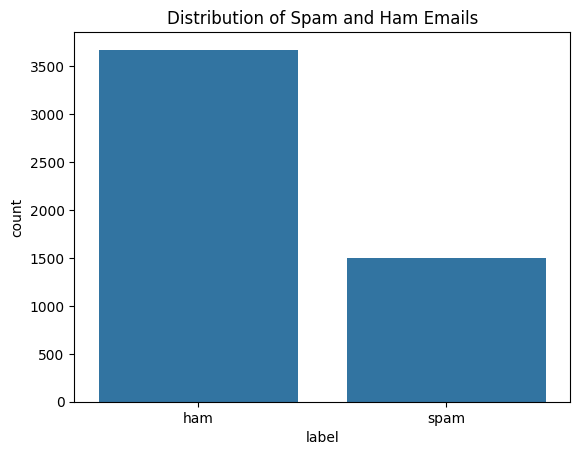

In [6]:
sns.countplot(x='label', data=data)
plt.title('Distribution of Spam and Ham Emails')
plt.show()

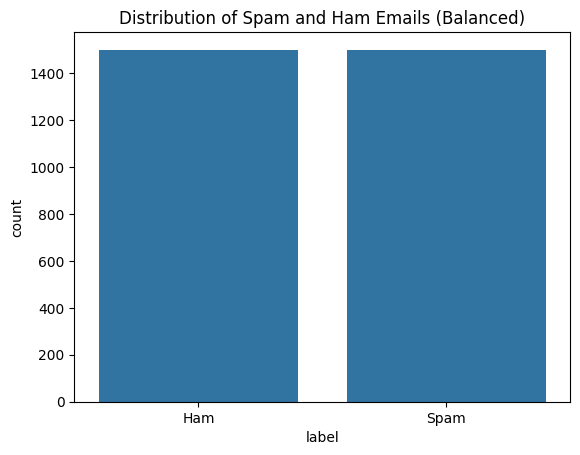

In [ ]:
ham_smg = data[data['label'] == 'ham']
spam_smg = data[data['label'] == 'spam']
ham_smg.balanced = ham_smg.sample(n=len(spam_smg), random_state=42)

balanced_data = pd.concat([ham_smg.balanced, spam_smg]).reset_index(drop=True)

sns.countplot(x='label', data=balanced_data)
plt.title('Distribution of Spam and Ham Emails (Balanced)')
plt.xticks(ticks = [0, 1], labels=['Ham', 'Spam'])
plt.show()

In [8]:
balanced_data['text']= balanced_data['text'].str.replace('Subject:','')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco - big cowboy\r\ndarren :\r\ni ' m not ...,0
1,2982,ham,feb 01 prod : sale to teco gas processing\r\n...,0
2,2711,ham,"california energy crisis\r\ncalifornia  , s ...",0
3,3116,ham,re : nom / actual volume for april 23 rd\r\nw...,0
4,1314,ham,eastrans nomination changes effective 8 / 2 /...,0


In [9]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)

balanced_data['text']= balanced_data['text'].apply(lambda x: remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [10]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')
    imp_words = []
    
    for word in str(text).split():
        word = word.lower ()
        
        if word not in stop_words:
            imp_words.append(word)
    output = ' '.join(imp_words)
    return output
balanced_data['text'] = balanced_data['text'].apply(lambda text : remove_stopwords(text))
balanced_data.head()


,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


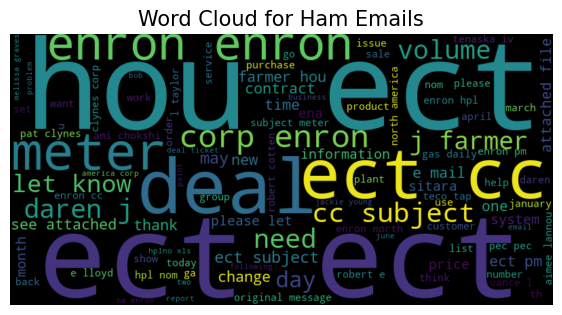

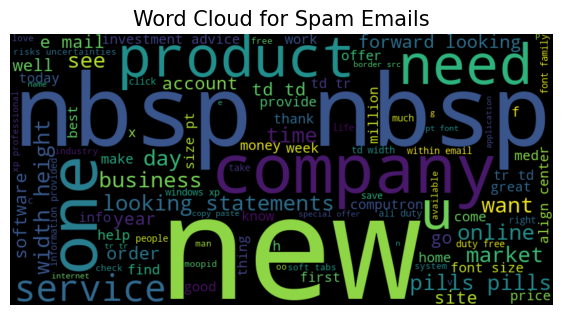

In [11]:
# Visualize the most common words in spam and ham emails using word clouds
def plot_word_cloud(data,typ):
    email_corpus = ' '.join(data['text'])
    wc = WordCloud(background_color='black', max_words = 100, width = 800, height= 400).generate(email_corpus)
    plt.figure(figsize=(7,7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Word Cloud for {typ} Emails', fontsize=15)
    plt.axis('off') 
    plt.show()
    
plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ = 'Ham')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ = 'Spam')

In [12]:
# Tokenization and Padding  
train_X, test_X, train_Y, test_Y = train_test_split(balanced_data['text'], balanced_data['label'], test_size=0.2, random_state=42)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100 
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')

train_Y = (train_Y == 'spam').astype(int)
test_Y = (test_Y == 'spam').astype(int)

In [13]:
# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) +1, output_dim =32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid') #output layer for binary classification
])
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer = 'adam',
    metrics = ['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
es = EarlyStopping(patience= 3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor= 0.5, verbose= 0 )

history  = model.fit(
    train_sequences, train_Y,
    validation_data = (test_sequences, test_Y),
    epochs = 20,
    batch_size = 32,
    callbacks = [lr, es]
    
)

Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6101 - loss: 0.6616 - val_accuracy: 0.9500 - val_loss: 0.3080 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9500 - loss: 0.2128 - val_accuracy: 0.9533 - val_loss: 0.1842 - learning_rate: 0.0010
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9583 - loss: 0.1738 - val_accuracy: 0.9650 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9683 - loss: 0.1370 - val_accuracy: 0.9583 - val_loss: 0.1784 - learning_rate: 0.0010
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9683 - loss: 0.1473 - val_accuracy: 0.9600 - val_loss: 0.1623 - learning_rate: 0.0010
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9587 - loss: 0.1712 - val_accuracy: 0.9633 - val_loss: 0.1490 - learning_rate: 5.0000e-04


In [15]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9650 - loss: 0.1470
Test Loss: 0.1470
Test Accuracy: 0.9650


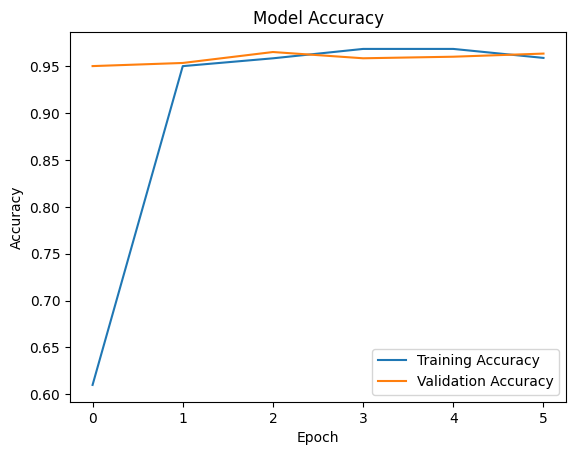

In [16]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Classification Report:

              precision    recall  f1-score   support

         Ham       0.99      0.95      0.97       315
        Spam       0.94      0.99      0.96       285

    accuracy                           0.96       600
   macro avg       0.96      0.97      0.96       600
weighted avg       0.97      0.96      0.97       600



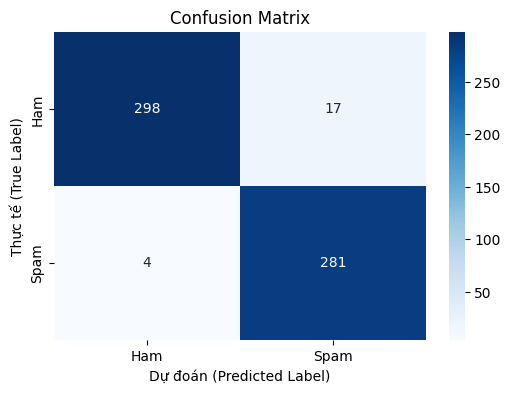

In [17]:

# Dự đoán trên tập test (kết quả trả về là xác suất từ sigmoid)
y_pred_prob = model.predict(test_sequences)
# Chuyển đổi xác suất thành nhãn 0 hoặc 1 (ngưỡng 0.5)
y_pred = (y_pred_prob > 0.5).astype(int)

# Báo cáo chi tiết (Precision, Recall, F1-Score)
print("Classification Report:\n")
print(classification_report(test_Y, y_pred, target_names=['Ham', 'Spam']))

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(test_Y, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.show()

In [18]:
# Lưu kiến trúc và trọng số của model
model.save('spam_classifier_model.h5')

# Lưu Tokenizer (rất quan trọng, nếu không có cái này bạn không thể chuyển chữ thành số ở lần sau)
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Đã lưu mô hình và Tokenizer thành công!")

Đã lưu mô hình và Tokenizer thành công!


In [19]:
# Deployment (Sử dụng mô hình đã lưu để dự đoán trên dữ liệu mới)
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.
